In [114]:
from simfile import SimFile
from simulation import Simulation
from validation import switchOffAllEffects, fitGaussian2D
import os
import matplotlib.pyplot as plt
import referenceFrames as rf
import numpy as np
import math

In [115]:
sim = Simulation("PSF")
switchOffAllEffects(sim)
sim.outputDir = os.environ["PLATO_WORKDIR"]

# One full-frame exposure

sim["ObservingParameters/NumExposures"] = 1

sim["CCD/IncludeConvolution"] = "yes"

starCatalogFilename = os.environ["PLATO_WORKDIR"] + "generatedFromPixelCoordinates.starcat"
sim.createStarCatalogFileFromPixelCoordinates(np.array([100]), np.array([100]), np.array([12.5]), np.array([1]), starCatalogFilename)
sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename

dim = 20
sim["SubField/NumRows"] = dim
sim["SubField/NumColumns"] = dim
sim["SubField/ZeroPointRow"] = 100 - dim // 2
sim["SubField/ZeroPointColumn"] = 100 - dim // 2

sim["ControlHDF5Content/WriteSubPixelImages"] = "yes"
numSubPixels = sim["SubField/SubPixels"]


# Gaussian PSF

In [116]:
sim["PSF/Model"] = "MappedGaussian"
sigma = sim["PSF/MappedGaussian/Sigma"]

output = sim.run(removeOutputFile = True)
image = output.getImage(0)
subPixelImage = output.getSubPixelImage(0)

In [117]:
offsets = np.arange(0.0, 0.5, 0.1/numSubPixels)

fittedSigmaPixel = np.array([])
fittedRowsPixel = np.array([])
fittedColumnsPixel = np.array([])
fittedSigmaSubPixel = np.array([])
fittedRowsSubPixel = np.array([])
fittedColumnsSubPixel = np.array([])
    
for offset in offsets:

    sim.createStarCatalogFileFromPixelCoordinates(np.array([100 + offset]), np.array([100 + offset]), np.array([12.5]), np.array([1]), starCatalogFilename)
    sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename
    
    sim["PSF/Model"] = "MappedGaussian"
    sigma = sim["PSF/MappedGaussian/Sigma"]

    output = sim.run(removeOutputFile = True)
    image = output.getImage(0)
    subPixelImage = output.getSubPixelImage(0)
    
    print("Offset:", offset)
    print("******* \n")
    
    params = fitGaussian2D(image, np.max(image), dim / 2, dim / 2, sigma, sigma, subtractConstant = True)
    print("Pixel level:")
    print("------------")
    print("Position:", params[1], params[2])
    print("Sigma:", params[3], "\n")
    fittedSigmaPixel = np.append(fittedSigmaPixel, params[3])
    fittedRowsPixel = np.append(fittedRowsPixel, params[1])
    fittedColumnsPixel = np.append(fittedColumnsPixel, params[2])

    params = fitGaussian2D(subPixelImage, np.max(subPixelImage), dim * numSubPixels / 2, dim * numSubPixels / 2, sigma * numSubPixels, sigma * numSubPixels, subtractConstant = True)
    print("Sub-pixel level:")
    print("----------------")
    print("Position:", params[1] / numSubPixels, params[2] / numSubPixels)
    print("Sigma:", params[3] / numSubPixels)
    fittedSigmaSubPixel = np.append(fittedSigmaSubPixel, params[3] / numSubPixels)
    fittedRowsSubPixel = np.append(fittedRowsSubPixel, params[1] / numSubPixels)
    fittedColumnsSubPixel = np.append(fittedColumnsSubPixel, params[2] / numSubPixels)



Offset: 0.0
******* 

Pixel level:
------------
Position: 9.438208412264942 9.438208418082656
Sigma: 0.7011502539879009 

Sub-pixel level:
----------------
Position: 9.874999998805453 9.875000005381038
Sigma: 0.6390004212100916


Offset: 0.0125
******* 

Pixel level:
------------
Position: 9.561791586231026 9.561791585352433
Sigma: 0.7011502169977406 

Sub-pixel level:
----------------
Position: 10.000000003097252 9.999999999319336
Sigma: 0.6390004179659304


Offset: 0.025
******* 

Pixel level:
------------
Position: 9.561791586231026 9.561791585352433
Sigma: 0.7011502169977406 

Sub-pixel level:
----------------
Position: 10.000000003097252 9.999999999319336
Sigma: 0.6390004179659307


Offset: 0.037500000000000006
******* 

Pixel level:
------------
Position: 9.561791586231026 9.561791585352433
Sigma: 0.7011502169977406 

Sub-pixel level:
----------------
Position: 10.000000003097252 9.999999999319336
Sigma: 0.6390004179659304


Offset: 0.05
******* 

Pixel level:
------------
Posi



Offset: 0.4375
******* 

Pixel level:
------------
Position: 9.9370172999098 9.93701726956779
Sigma: 0.7045927258271353 

Sub-pixel level:
----------------
Position: 10.375000003989598 10.375000014019864
Sigma: 0.6390004156270916


Offset: 0.45
******* 

Pixel level:
------------
Position: 9.9370172999098 9.93701726956779
Sigma: 0.7045927258271353 

Sub-pixel level:
----------------
Position: 10.375000003989602 10.375000014019864
Sigma: 0.6390004156270949


Offset: 0.4625
******* 

Pixel level:
------------
Position: 9.9370172999098 9.93701726956779
Sigma: 0.7045927258271353 

Sub-pixel level:
----------------
Position: 10.375000003989598 10.375000014019864
Sigma: 0.6390004156270916


Offset: 0.47500000000000003
******* 

Pixel level:
------------
Position: 9.9370172999098 9.93701726956779
Sigma: 0.7045927258271353 

Sub-pixel level:
----------------
Position: 10.375000003989602 10.375000014019864
Sigma: 0.6390004156270949


Offset: 0.48750000000000004
******* 

Pixel level:
--------

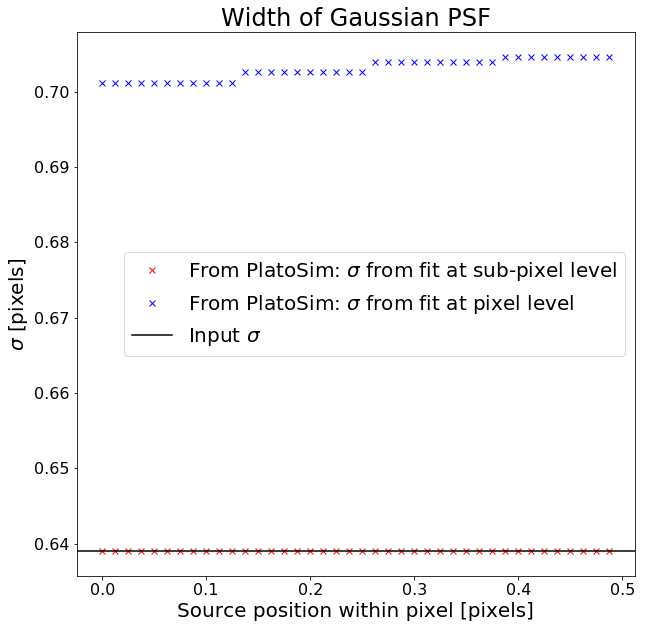

In [118]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



plt.plot(offsets, fittedSigmaSubPixel, "rx", label = "From PlatoSim: $\\sigma$ from fit at sub-pixel level")
plt.plot(offsets, fittedSigmaPixel, "bx", label = "From PlatoSim: $\\sigma$ from fit at pixel level")

plt.axhline(y = sigma, color = "k", label = "Input $\\sigma$")


########
# Layout
########

plt.title("Width of Gaussian PSF", fontsize = 24)
plt.xlabel("Source position within pixel [pixels]", fontsize = 20)
plt.ylabel("$\\sigma$ [pixels]", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)


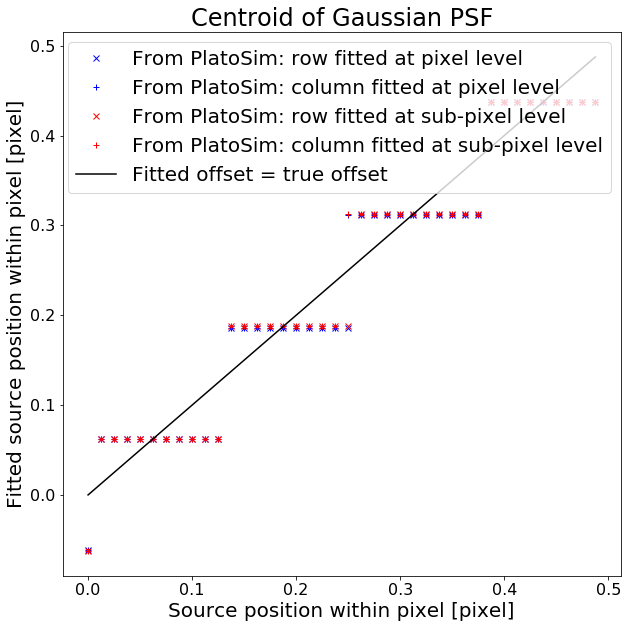

In [119]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



plt.plot(offsets, fittedRowsPixel + 0.5 - (dim / 2), "bx", label = "From PlatoSim: row fitted at pixel level")
plt.plot(offsets, fittedColumnsPixel + 0.5 - (dim / 2), "b+", label = "From PlatoSim: column fitted at pixel level")

plt.plot(offsets, fittedRowsSubPixel + 0.5 / numSubPixels - (dim / 2), "rx", label = "From PlatoSim: row fitted at sub-pixel level")
plt.plot(offsets, fittedColumnsSubPixel + 0.5 / numSubPixels - (dim / 2), "r+", label = "From PlatoSim: column fitted at sub-pixel level")

plt.plot(offsets, (dim / 2) + offsets - (dim / 2), "k", label = "Fitted offset = true offset")

########
# Layout
########

plt.title("Centroid of Gaussian PSF", fontsize = 24)
plt.xlabel("Source position within pixel [pixel]", fontsize = 20)
plt.ylabel("Fitted source position within pixel [pixel]", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

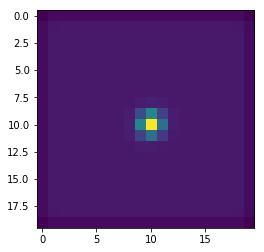

In [120]:
plt.imshow(image)

In [121]:
ID, rows, columns, Xmm, Ymm, flux = output.getStarCoordinates(0)

# Pre-Computed PSF

In [122]:
offsets = np.arange(0.0, 0.5, 0.1/numSubPixels)

fittedSigmaPixel = np.array([])
fittedRowsPixel = np.array([])
fittedColumnsPixel = np.array([])
fittedSigmaSubPixel = np.array([])
fittedRowsSubPixel = np.array([])
fittedColumnsSubPixel = np.array([])
    
for offset in offsets:

    sim.createStarCatalogFileFromPixelCoordinates(np.array([100 + offset]), np.array([100 + offset]), np.array([12.5]), np.array([1]), starCatalogFilename)
    sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename
    
    sim["PSF/Model"] = "MappedFromFile"

    output = sim.run(removeOutputFile = True)
    image = output.getImage(0)
    subPixelImage = output.getSubPixelImage(0)
    
    print("Offset:", offset)
    print("******* \n")
    
    params = fitGaussian2D(image, np.max(image), dim / 2, dim / 2, sigma, sigma, subtractConstant = True)
    print("Pixel level:")
    print("------------")
    print("Position:", params[1], params[2])
    print("Sigma:", params[3], "\n")
    fittedSigmaPixel = np.append(fittedSigmaPixel, params[3])
    fittedRowsPixel = np.append(fittedRowsPixel, params[1])
    fittedColumnsPixel = np.append(fittedColumnsPixel, params[2])

    params = fitGaussian2D(subPixelImage, np.max(subPixelImage), dim * numSubPixels / 2, dim * numSubPixels / 2, sigma * numSubPixels, sigma * numSubPixels, subtractConstant = True)
    print("Sub-pixel level:")
    print("----------------")
    print("Position:", params[1] / numSubPixels, params[2] / numSubPixels)
    print("Sigma:", params[3] / numSubPixels)
    fittedSigmaSubPixel = np.append(fittedSigmaSubPixel, params[3] / numSubPixels)
    fittedRowsSubPixel = np.append(fittedRowsSubPixel, params[1] / numSubPixels)
    fittedColumnsSubPixel = np.append(fittedColumnsSubPixel, params[2] / numSubPixels)



Offset: 0.0
******* 

Pixel level:
------------
Position: 9.287778639852032 9.287778670021108
Sigma: 0.4706751267620457 

Sub-pixel level:
----------------
Position: 9.820736573856585 9.82073657835972
Sigma: 0.11136080417965408


Offset: 0.0125
******* 

Pixel level:
------------
Position: 9.515125394008091 9.515125417108345
Sigma: 0.533255481493235 

Sub-pixel level:
----------------
Position: 9.94573648221609 9.945736482152094
Sigma: 0.11136174281782892


Offset: 0.025
******* 

Pixel level:
------------
Position: 9.515125394008091 9.515125417108345
Sigma: 0.533255481493235 

Sub-pixel level:
----------------
Position: 9.945736482214933 9.945736482148043
Sigma: 0.11136174283258332


Offset: 0.037500000000000006
******* 

Pixel level:
------------
Position: 9.515125394008091 9.515125417108345
Sigma: 0.533255481493235 

Sub-pixel level:
----------------
Position: 9.945736482218653 9.945736482150068
Sigma: 0.11136174276074956


Offset: 0.05
******* 

Pixel level:
------------
Position



Offset: 0.4375
******* 

Pixel level:
------------
Position: 9.907148936028054 9.907148948399723
Sigma: 0.45066364164608036 

Sub-pixel level:
----------------
Position: 10.320736575232194 10.320736574796104
Sigma: 0.11136081727137201


Offset: 0.45
******* 

Pixel level:
------------
Position: 9.907148936028054 9.907148948399723
Sigma: 0.45066364164608036 

Sub-pixel level:
----------------
Position: 10.320736575235548 10.320736574800147
Sigma: 0.11136081721392023


Offset: 0.4625
******* 

Pixel level:
------------
Position: 9.907148936028054 9.907148948399723
Sigma: 0.45066364164608036 

Sub-pixel level:
----------------
Position: 10.320736575231692 10.320736574795596
Sigma: 0.11136081731662274


Offset: 0.47500000000000003
******* 

Pixel level:
------------
Position: 9.907148936028054 9.907148948399723
Sigma: 0.45066364164608036 

Sub-pixel level:
----------------
Position: 10.320736575232194 10.320736574796104
Sigma: 0.11136081727137201


Offset: 0.48750000000000004
******* 

P

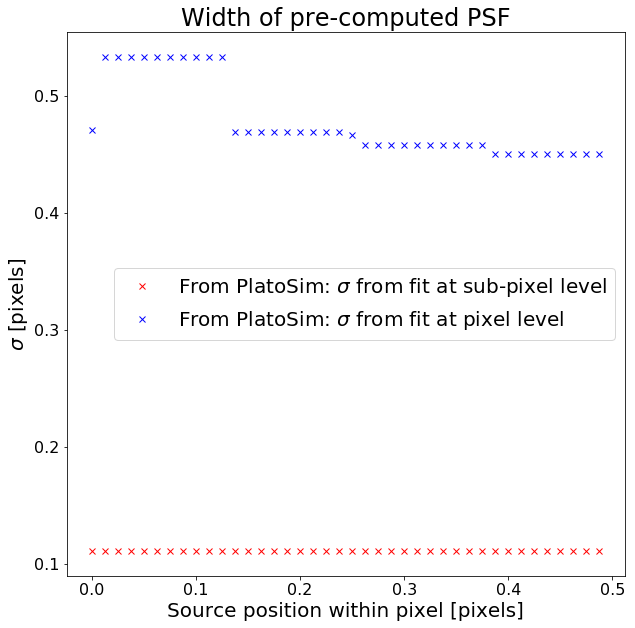

In [123]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



plt.plot(offsets, fittedSigmaSubPixel, "rx", label = "From PlatoSim: $\\sigma$ from fit at sub-pixel level")
plt.plot(offsets, fittedSigmaPixel, "bx", label = "From PlatoSim: $\\sigma$ from fit at pixel level")


########
# Layout
########

plt.title("Width of pre-computed PSF", fontsize = 24)
plt.xlabel("Source position within pixel [pixels]", fontsize = 20)
plt.ylabel("$\\sigma$ [pixels]", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)


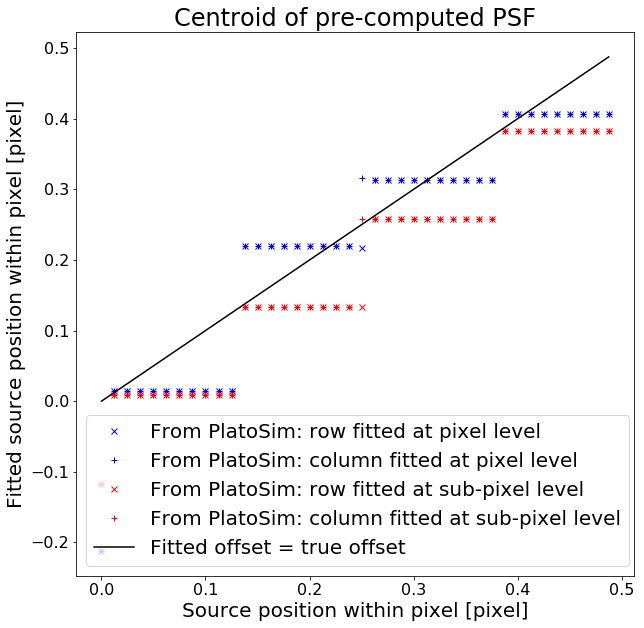

In [124]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



plt.plot(offsets, fittedRowsPixel + 0.5 - (dim / 2), "bx", label = "From PlatoSim: row fitted at pixel level")
plt.plot(offsets, fittedColumnsPixel + 0.5 - (dim / 2), "b+", label = "From PlatoSim: column fitted at pixel level")

plt.plot(offsets, fittedRowsSubPixel + 0.5 / numSubPixels - (dim / 2), "rx", label = "From PlatoSim: row fitted at sub-pixel level")
plt.plot(offsets, fittedColumnsSubPixel + 0.5 / numSubPixels - (dim / 2), "r+", label = "From PlatoSim: column fitted at sub-pixel level")

plt.plot(offsets, (dim / 2) + offsets - (dim / 2), "k", label = "Fitted offset = true offset")



########
# Layout
########

plt.title("Centroid of pre-computed PSF", fontsize = 24)
plt.xlabel("Source position within pixel [pixel]", fontsize = 20)
plt.ylabel("Fitted source position within pixel [pixel]", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

# Analytic PSF

In [126]:
offsets = np.arange(0.0, 0.5, 0.1/numSubPixels)

fittedSigmaPixel = np.array([])
fittedRowsPixel = np.array([])
fittedColumnsPixel = np.array([])
# fittedSigmaSubPixel = np.array([])
# fittedRowsSubPixel = np.array([])
# fittedColumnsSubPixel = np.array([])
    
for offset in offsets:

    sim.createStarCatalogFileFromPixelCoordinates(np.array([100 + offset]), np.array([100 + offset]), np.array([12.5]), np.array([1]), starCatalogFilename)
    sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename
    
    sim["PSF/Model"] = "AnalyticNonGaussian"

    output = sim.run(removeOutputFile = True)
    image = output.getImage(0)
    
    print("Offset:", offset)
    print("******* \n")
    
    params = fitGaussian2D(image, np.max(image), dim / 2, dim / 2, sigma, sigma, subtractConstant = True)
    print("Pixel level:")
    print("------------")
    print("Position:", params[1], params[2])
    print("Sigma:", params[3], "\n")
    fittedSigmaPixel = np.append(fittedSigmaPixel, params[3])
    fittedRowsPixel = np.append(fittedRowsPixel, params[1])
    fittedColumnsPixel = np.append(fittedColumnsPixel, params[2])



Offset: 0.0
******* 

Pixel level:
------------
Position: 9.472546304781558 9.4725463047901
Sigma: 0.5353787795532102 



Offset: 0.0125
******* 

Pixel level:
------------
Position: 9.519448517192403 9.519448517194954
Sigma: 0.537151316335389 



Offset: 0.025
******* 

Pixel level:
------------
Position: 9.563265854763653 9.563265855092043
Sigma: 0.5281499546033022 



Offset: 0.037500000000000006
******* 

Pixel level:
------------
Position: 9.598186089959025 9.598186089959025
Sigma: 0.5155300075024835 



Offset: 0.05
******* 

Pixel level:
------------
Position: 9.623468066569762 9.62346806717829
Sigma: 0.5052490119232751 



Offset: 0.0625
******* 

Pixel level:
------------
Position: 9.641541064586606 9.641541066341068
Sigma: 0.4983568140354899 



Offset: 0.07500000000000001
******* 

Pixel level:
------------
Position: 9.655976346158205 9.655976347369036
Sigma: 0.4934655793768277 



Offset: 0.08750000000000001
******* 

Pixel level:
------------
Position: 9.669859417078065 

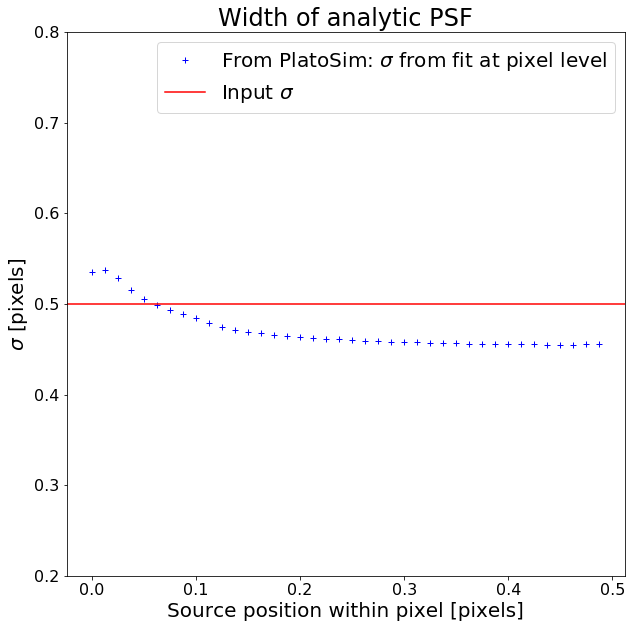

In [127]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)


sigma = sim["PSF/AnalyticNonGaussian/Sigma/ConstantValue"]
plt.plot(offsets, fittedSigmaPixel, "b+", label = "From PlatoSim: $\\sigma$ from fit at pixel level")

plt.axhline(y = sigma, color = "r", label = "Input $\\sigma$")


########
# Layout
########

plt.title("Width of analytic PSF", fontsize = 24)
plt.xlabel("Source position within pixel [pixels]", fontsize = 20)
plt.ylabel("$\\sigma$ [pixels]", fontsize = 20)
plt.ylim([0.2, 0.8])

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)


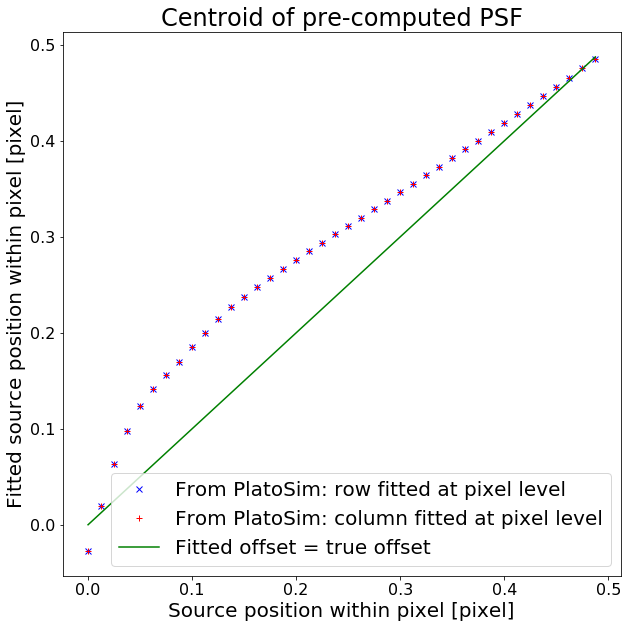

In [128]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



plt.plot(offsets, fittedRowsPixel + 0.5 - (dim / 2), "bx", label = "From PlatoSim: row fitted at pixel level")
plt.plot(offsets, fittedColumnsPixel + 0.5 - (dim / 2), "r+", label = "From PlatoSim: column fitted at pixel level")
plt.plot(offsets, (dim / 2) + offsets - (dim / 2), "g", label = "Fitted offset = true offset")



########
# Layout
########

plt.title("Centroid of pre-computed PSF", fontsize = 24)
plt.xlabel("Source position within pixel [pixel]", fontsize = 20)
plt.ylabel("Fitted source position within pixel [pixel]", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)